# 演算法時間複雜度：泡沫排序 vs 合併排序

1. 什麼是時間複雜度
2. 什麼是 Big-O 大 O 表示法
3. 為什麼只看最高階項
4. 泡沫排序 Bubble Sort 的時間複雜度：`O(n^2)`
5. 合併排序 Merge Sort 的時間複雜度：`O(n log n)`
6. 用實際測速比較兩種排序的差異


## 1. 什麼是時間複雜度？

時間複雜度是在描述：

> 當輸入資料量 `n` 變大時，程式執行時間大概會怎麼成長。

例如：

```text
n = 10
n = 100
n = 1000
n = 10000
```

我們不只關心程式現在跑幾秒，更關心：

> 資料量變成 10 倍時，時間會變成幾倍？

---

常見時間複雜度：

| 複雜度 | 名稱 | 例子 |
|---|---|---|
| `O(1)` | 常數時間 | 取 list 第 0 個元素 |
| `O(log n)` | 對數時間 | 二分搜尋 |
| `O(n)` | 線性時間 | 掃過整個 list |
| `O(n log n)` | 線性對數 | 合併排序、快速排序平均 |
| `O(n^2)` | 平方時間 | 泡沫排序、選擇排序 |
| `O(2^n)` | 指數時間 | 某些暴力遞迴 |


## 2. Big-O 大 O 表示法

Big-O 主要看「成長趨勢」，不是精準計算每一步。

所以常數與較小項通常會被忽略。

例如：

```text
O(5) = O(1)
O(2n + 1) = O(n)
O(n^2 + n + 1) = O(n^2)
O(3n^3 + 100n) = O(n^3)
```

因為當 `n` 很大時，最高階項影響最大。


In [2]:
# 看看 n 很大時，最高階項影響有多大

for n in [10, 100, 1000, 10000]:
    value = n**2 + n + 1
    highest = n**2
    ratio = highest / value
    print(f"n = {n:5d}, n^2+n+1 = {value:12d}, n^2 佔比 = {ratio:.4f}")

n =    10, n^2+n+1 =          111, n^2 佔比 = 0.9009
n =   100, n^2+n+1 =        10101, n^2 佔比 = 0.9900
n =  1000, n^2+n+1 =      1001001, n^2 佔比 = 0.9990
n = 10000, n^2+n+1 =    100010001, n^2 佔比 = 0.9999


## 3. 用程式感受不同複雜度的成長速度

下面先用數字表格比較：

- `n`
- `n log n`
- `n^2`

當 `n` 越大，`n^2` 會成長得非常快。


In [3]:
import math

sizes = [10, 100, 1_000, 10_000, 100_000]

print(f"{'n':>10} {'n log2 n':>15} {'n^2':>20}")
print("-" * 50)

for n in sizes:
    nlogn = n * math.log2(n)
    n2 = n ** 2
    print(f"{n:>10,} {nlogn:>15,.0f} {n2:>20,}")

         n        n log2 n                  n^2
--------------------------------------------------
        10              33                  100
       100             664               10,000
     1,000           9,966            1,000,000
    10,000         132,877          100,000,000
   100,000       1,660,964       10,000,000,000


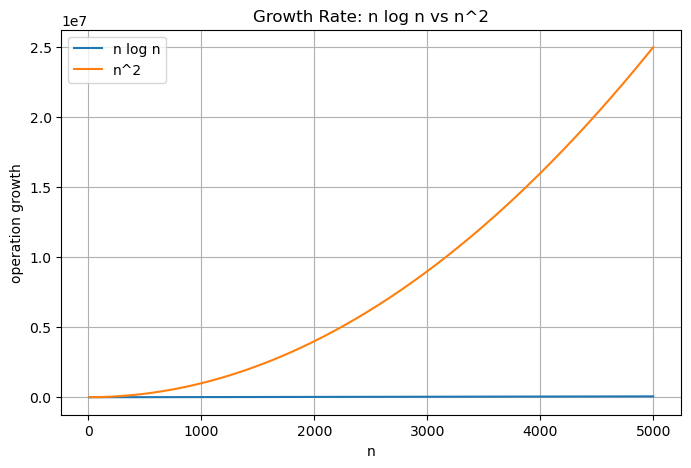

In [4]:
# 視覺化：n log n vs n^2

import matplotlib.pyplot as plt
import math

xs = list(range(10, 5001, 10))
y_nlogn = [x * math.log2(x) for x in xs]
y_n2 = [x ** 2 for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, y_nlogn, label="n log n")
plt.plot(xs, y_n2, label="n^2")
plt.xlabel("n")
plt.ylabel("operation growth")
plt.title("Growth Rate: n log n vs n^2")
plt.legend()
plt.grid(True)
plt.show()

# Part A：泡沫排序 Bubble Sort

## 4. 泡沫排序概念

泡沫排序的想法：

> 不斷比較相鄰兩個元素，如果順序錯了就交換。

例如從小排到大：

```text
[5, 3, 8, 1]
```

先比：

```text
5 和 3：順序錯，交換
[3, 5, 8, 1]
```

再比：

```text
5 和 8：順序對，不換
[3, 5, 8, 1]
```

再比：

```text
8 和 1：順序錯，交換
[3, 5, 1, 8]
```

跑完一輪後，最大的數會被推到最後面，像泡泡浮上去。


In [5]:
def bubble_sort(arr):
    a = arr[:]  # 複製一份，避免改到原本的資料
    n = len(a)

    for i in range(n):
        for j in range(0, n - 1 - i):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]

    return a


data = [5, 3, 8, 1, 2]
print("原本:", data)
print("排序後:", bubble_sort(data))

原本: [5, 3, 8, 1, 2]
排序後: [1, 2, 3, 5, 8]


## 5. 泡沫排序的時間複雜度

泡沫排序有兩層迴圈：

```python
for i in range(n):
    for j in range(0, n - 1 - i):
        ...
```

比較次數大約是：

```text
(n-1) + (n-2) + (n-3) + ... + 1
```

這是一個等差級數：

```text
n(n-1) / 2
```

展開：

```text
(n^2 - n) / 2
```

Big-O 忽略常數與較小項：

```text
O((n^2 - n) / 2) = O(n^2)
```

所以泡沫排序是：

```text
O(n^2)
```


In [6]:
def bubble_sort_count(arr):
    a = arr[:]
    n = len(a)
    comparisons = 0
    swaps = 0

    for i in range(n):
        for j in range(0, n - 1 - i):
            comparisons += 1

            if a[j] > a[j + 1]:
                swaps += 1
                a[j], a[j + 1] = a[j + 1], a[j]

    return a, comparisons, swaps


for n in [5, 10, 100]:
    data = list(range(n, 0, -1))  # 反向資料，接近最差情況
    _, comparisons, swaps = bubble_sort_count(data)
    formula = n * (n - 1) // 2

    print(f"n = {n}")
    print("實際比較次數:", comparisons)
    print("公式 n(n-1)/2:", formula)
    print("交換次數:", swaps)
    print()

n = 5
實際比較次數: 10
公式 n(n-1)/2: 10
交換次數: 10

n = 10
實際比較次數: 45
公式 n(n-1)/2: 45
交換次數: 45

n = 100
實際比較次數: 4950
公式 n(n-1)/2: 4950
交換次數: 4950



## 6. 泡沫排序優化版：如果已經排序好就提早停止

如果某一輪完全沒有交換，代表資料已經排序好了，可以提前結束。

這樣在「已排序資料」上可以接近 `O(n)`。

但是在平均或最差情況下，仍然是 `O(n^2)`。


In [7]:
def bubble_sort_optimized(arr):
    a = arr[:]
    n = len(a)

    for i in range(n):
        swapped = False

        for j in range(0, n - 1 - i):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True

        if not swapped:
            break

    return a


data = [1, 2, 3, 4, 5]
print(bubble_sort_optimized(data))

[1, 2, 3, 4, 5]


# Part B：合併排序 Merge Sort

## 7. 合併排序概念

合併排序使用 Divide and Conquer，中文常叫：

> 分治法

做法：

1. 把資料切成左右兩半
2. 左半邊排序
3. 右半邊排序
4. 把兩個已排序的 list 合併起來

例如：

```text
[5, 3, 8, 1]
```

切成：

```text
[5, 3] 和 [8, 1]
```

再切：

```text
[5] [3] [8] [1]
```

合併排序後：

```text
[3, 5] 和 [1, 8]
```

最後合併：

```text
[1, 3, 5, 8]
```


In [ ]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr[:]

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


data = [5, 3, 8, 1, 2]
print("原本:", data)
print("排序後:", merge_sort(data))

原本: [5, 3, 8, 1, 2]
排序後: [1, 2, 3, 5, 8]


## 8. 合併排序的時間複雜度

合併排序每一層都會把所有元素合併一次，所以每層大約做：

```text
O(n)
```

問題是會有幾層？

因為每次都把資料切一半：

```text
n -> n/2 -> n/4 -> n/8 -> ... -> 1
```

切到剩 1 個元素，大約需要：

```text
log2(n)
```

層。

所以總時間：

```text
每層 O(n) × 總共 O(log n) 層 = O(n log n)
```

也可以寫成遞迴式：

```text
T(n) = 2T(n/2) + O(n)
```

意思是：

- `2T(n/2)`：左半邊排序 + 右半邊排序
- `O(n)`：合併兩個已排序 list

結果是：

```text
T(n) = O(n log n)
```


In [9]:
def show_merge_sort_tree(n, level=0):
    print("  " * level + f"n = {n}")

    if n <= 1:
        return

    show_merge_sort_tree(n // 2, level + 1)
    show_merge_sort_tree(n - n // 2, level + 1)


show_merge_sort_tree(8)

n = 8
  n = 4
    n = 2
      n = 1
      n = 1
    n = 2
      n = 1
      n = 1
  n = 4
    n = 2
      n = 1
      n = 1
    n = 2
      n = 1
      n = 1


## 9. 用「每層工作量」看懂 `n log n`

以 `n = 8` 為例：

```text
第 0 層：1 個問題，每個大小 8，總工作量 8
第 1 層：2 個問題，每個大小 4，總工作量 8
第 2 層：4 個問題，每個大小 2，總工作量 8
第 3 層：8 個問題，每個大小 1，總工作量 8
```

每層大約都做 `n` 的工作。

層數大約是 `log2(n)`。

所以：

```text
n + n + n + ... + n
```

共有 `log n` 層，因此：

```text
O(n log n)
```


In [10]:
def merge_sort_level_work(n):
    level = 0
    size = n

    while size >= 1:
        parts = 2 ** level
        print(f"第 {level} 層：大約 {parts} 個子問題，總工作量約 {n}")
        size //= 2
        level += 1


merge_sort_level_work(8)

第 0 層：大約 1 個子問題，總工作量約 8
第 1 層：大約 2 個子問題，總工作量約 8
第 2 層：大約 4 個子問題，總工作量約 8
第 3 層：大約 8 個子問題，總工作量約 8


# Part C：實際測速比較

## 10. 泡沫排序 vs 合併排序

接下來實際用隨機資料測速。

注意：

- 測速結果會受到電腦、Python 版本、背景程式影響
- 不要死背秒數
- 要觀察的是：`n` 變大時，誰成長比較快


In [11]:
import random
from time import perf_counter

def benchmark_sort(sort_func, data):
    start = perf_counter()
    result = sort_func(data)
    end = perf_counter()
    return end - start, result


sizes = [100, 300, 600, 1000, 1500]

print(f"{'n':>8} {'bubble_sort':>15} {'merge_sort':>15}")
print("-" * 42)

for n in sizes:
    data = [random.randint(1, 1_000_000) for _ in range(n)]

    bubble_time, bubble_result = benchmark_sort(bubble_sort, data)
    merge_time, merge_result = benchmark_sort(merge_sort, data)

    assert bubble_result == merge_result

    print(f"{n:>8} {bubble_time:>15.6f} {merge_time:>15.6f}")

       n     bubble_sort      merge_sort
------------------------------------------
     100        0.000609        0.000350
     300        0.002711        0.000292
     600        0.022740        0.001234
    1000        0.047179        0.001565
    1500        0.068666        0.001670


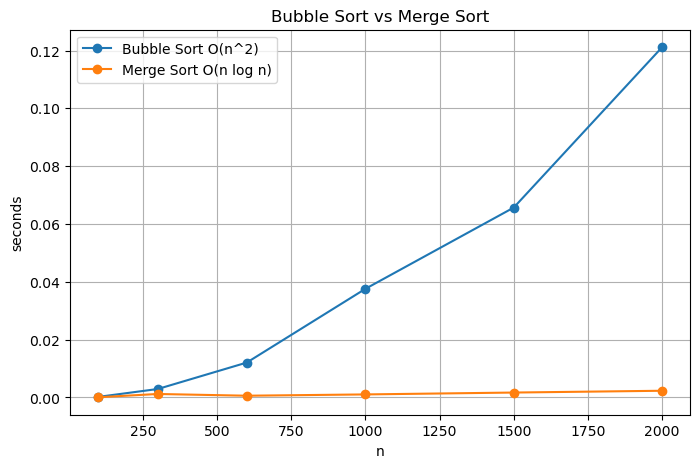

In [12]:
# 畫出測速結果

sizes = [100, 300, 600, 1000, 1500, 2000]
bubble_times = []
merge_times = []

for n in sizes:
    data = [random.randint(1, 1_000_000) for _ in range(n)]

    bubble_time, _ = benchmark_sort(bubble_sort, data)
    merge_time, _ = benchmark_sort(merge_sort, data)

    bubble_times.append(bubble_time)
    merge_times.append(merge_time)

plt.figure(figsize=(8, 5))
plt.plot(sizes, bubble_times, marker="o", label="Bubble Sort O(n^2)")
plt.plot(sizes, merge_times, marker="o", label="Merge Sort O(n log n)")
plt.xlabel("n")
plt.ylabel("seconds")
plt.title("Bubble Sort vs Merge Sort")
plt.legend()
plt.grid(True)
plt.show()

## 11. 為什麼資料量小時不一定看得出差異？

有時候 `n` 很小時，兩個演算法看起來差不多。

原因是：

1. 函式呼叫成本
2. Python list slicing 成本
3. 電腦背景程式干擾
4. 小資料時，常數時間影響比較明顯

所以時間複雜度主要看的是：

> 當 `n` 很大時的成長趨勢。


# Part D：比較表

| 演算法 | 思想 | 平均時間 | 最差時間 | 空間 |
|---|---|---:|---:|---:|
| 泡沫排序 | 相鄰比較與交換 | `O(n^2)` | `O(n^2)` | `O(1)` |
| 合併排序 | 分治法 | `O(n log n)` | `O(n log n)` | `O(n)` |

---

泡沫排序：

```text
兩層迴圈，所以常見是 O(n^2)
```

合併排序：

```text
每層 O(n)，總共 log n 層，所以 O(n log n)
```


## 12. 課堂練習 1：判斷複雜度

請問下面程式是什麼時間複雜度？

```python
for i in range(n):
    print(i)
```

答案：`O(n)`

---

請問下面程式是什麼時間複雜度？

```python
for i in range(n):
    for j in range(n):
        print(i, j)
```

答案：`O(n^2)`


## 13. 課堂練習 2：泡沫排序比較次數

如果 `n = 5`，泡沫排序最多會比較幾次？

公式：

```text
n(n-1)/2
```

代入：

```text
5 * 4 / 2 = 10
```


In [13]:
n = 5
print(n * (n - 1) // 2)

10


## 14. 課堂練習 3：合併排序層數

如果 `n = 16`，每次切一半，會切幾層到 1？

```text
16 -> 8 -> 4 -> 2 -> 1
```

大約是：

```text
log2(16) = 4
```


In [14]:
import math

n = 16
print(math.log2(n))

4.0


# 總結

時間複雜度看的是資料量變大時，演算法的成長速度。

Big-O 常用規則：

```text
忽略常數
忽略低階項
只看最高階項
```

泡沫排序：

```text
O(n^2)
```

因為有大量兩兩比較。

合併排序：

```text
O(n log n)
```

因為每層合併需要 `O(n)`，總共有 `O(log n)` 層。
